# Clase 7: Document loaders


Los  **Document Loaders** en LangChain, son el primer paso para procesar datos no estructurados. Exploraremos cómo cargar documentos de diferentes formatos, como PDFs y páginas web, y cómo dividirlos en fragmentos manejables utilizando *Text Splitters*.



### Cargar documentos desde un archivo PDF

Cargamos un documento PDF utilizando `PyPDFLoader`. Este loader extrae texto y metadatos de archivos PDF.


In [9]:
from langchain.document_loaders import PyPDFLoader

In [10]:
output_path = ".content/"
file_path = output_path + 'attention.pdf'

In [11]:
loader = PyPDFLoader(file_path) # instancia.
pages = loader.load()



Podemos inspeccionar el contenido cargado:


In [12]:
pages

[Document(metadata={'source': '.content/attention.pdf', 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlukaszkaiser@google.com\nIllia Polosukhin∗ ‡\nillia.polosukhin@gmail.com\nAbstract\nThe dominant sequence transduction models are based on complex recurrent or\nconvolutional neural networks that include an encoder and a decoder. The best\nperforming models also connect the encoder and decoder through an attention\nmechanism. We propose a new simple ne

In [13]:
import pprint
loader = PyPDFLoader(
    file_path,
    mode="single",
)
docs = loader.load()
print(len(docs))
pprint.pp(docs[0].metadata)

TypeError: PyPDFLoader.__init__() got an unexpected keyword argument 'mode'

In [14]:
pages = loader.load()

## Extracción de Texto de una Página Específica

Una vez cargado el documento, podemos acceder al contenido de cada página individualmente. Esto es útil para analizar o mostrar secciones específicas del PDF.

In [7]:
# Mostrar el contenido de la primera página
first_page = pages[0]
print("Contenido de la primera página:")
print(first_page.page_content)

Contenido de la primera página:
Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Parmar∗
Google Research
nikip@google.com
Jakob Uszkoreit∗
Google Research
usz@google.com
Llion Jones∗
Google Research
llion@google.com
Aidan N. Gomez∗ †
University of Toronto
aidan@cs.toronto.edu
Łukasz Kaiser∗
Google Brain
lukaszkaiser@google.com
Illia Polosukhin∗ ‡
illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or
convolutional neural networks that include an encoder and a decoder. The best
performing models also connect the encoder and decoder through an attention
mechanism. We propose a new simple network architecture, the Transformer,
based solely on attention mechanisms, dispensing with recurrenc

## Conteo de Palabras en el Documento

Podemos contar cuántas palabras hay en todo el documento sumando las palabras de cada página. Esto puede ser útil para análisis básicos de texto.

In [9]:
# Contar palabras totales en el documento
total_words = sum(len(doc.page_content.split()) for doc in pages)
print(f"El documento tiene {total_words} palabras en total.")

El documento tiene 6113 palabras en total.


## Búsqueda de Palabras Clave

Podemos buscar una palabra o frase específica en el documento y mostrar en qué páginas aparece. Esto es útil para encontrar contenido relevante rápidamente.

In [11]:
# Buscar una palabra clave en el documento
keyword = "attention"
for i, doc in enumerate(pages):
    if keyword.lower() in doc.page_content.lower():
        print(f"La palabra '{keyword}' aparece en la página {i + 1}")

La palabra 'attention' aparece en la página 1
La palabra 'attention' aparece en la página 2
La palabra 'attention' aparece en la página 3
La palabra 'attention' aparece en la página 4
La palabra 'attention' aparece en la página 5
La palabra 'attention' aparece en la página 6
La palabra 'attention' aparece en la página 7
La palabra 'attention' aparece en la página 9
La palabra 'attention' aparece en la página 10
La palabra 'attention' aparece en la página 11
La palabra 'attention' aparece en la página 12
La palabra 'attention' aparece en la página 13
La palabra 'attention' aparece en la página 14
La palabra 'attention' aparece en la página 15


## Cargar documentos desde una URL

**LangChain** también permite cargar texto desde páginas web utilizando `WebBaseLoader`. Este módulo facilita la extracción de texto directamente desde URLs específicas, permitiendo integrar contenido web en las cadenas de procesamiento de lenguaje.

## Cargar documentos desde una URL

**LangChain** también permite cargar texto desde páginas web utilizando `WebBaseLoader`. Este módulo facilita la extracción de texto directamente desde URLs específicas, permitiendo integrar contenido web en las cadenas de procesamiento de lenguaje.

### Nota: 

Para usar `WebBaseLoader`, necesitamos la biblioteca `beautifulsoup4`, que LangChain utiliza para analizar el HTML. Asegúrate de agregarla a tu entorno. Si usas el `.yml`, añade la línea:

```yaml
- pip:
  - beautifulsoup4
```
o instálalo directamente usando `pip` en tu ambiente

```bash
pip install beautifulsoup4
```



## Carga Básica de una Página Web

Comencemos cargando el contenido de una página web simple. Usaremos una URL de ejemplo

In [16]:
from langchain.document_loaders import WebBaseLoader

# Definimos la URL a cargar
url = "https://es.wikipedia.org/wiki/Inteligencia_artificial"

# Creamos una instancia del cargador y cargamos el contenido
loader = WebBaseLoader(url)
web_documents = loader.load()

# Mostramos una parte del contenido como verificación
print("Primeros 500 caracteres del contenido:")
print(web_documents[0].page_content[:500])

USER_AGENT environment variable not set, consider setting it to identify your requests.


Primeros 500 caracteres del contenido:




Inteligencia artificial - Wikipedia, la enciclopedia libre






































Ir al contenido







Menú principal





Menú principal
mover a la barra lateral
ocultar



		Navegación
	


PortadaPortal de la comunidadActualidadCambios recientesPáginas nuevasPágina aleatoriaAyudaNotificar un error





		specialpages-url|specialpages
	





















Buscar











Buscar






















Apariencia
















Donaciones

Crear una cuenta

Acceder









## Extracción de Títulos o Encabezados

Podemos procesar el contenido para buscar títulos o palabras clave. Aquí, simplemente mostramos el inicio del texto, pero podríamos usar expresiones regulares o herramientas adicionales para extraer encabezados.

In [17]:
# Mostrar el contenido inicial que podría incluir un título
print("Contenido inicial (posible título):")
print(web_documents[0].page_content[:200])

Contenido inicial (posible título):




Inteligencia artificial - Wikipedia, la enciclopedia libre






































Ir al contenido







Menú principal





Menú principal
mover a la barra lateral
ocultar



		Nav


## Conteo de Palabras en la Página Web

Al igual que con los PDFs, podemos contar las palabras totales del contenido cargado desde la web.

In [18]:
# Contar palabras en el contenido web
total_web_words = len(web_documents[0].page_content.split())
print(f"La página web tiene {total_web_words} palabras.")

La página web tiene 15356 palabras.


## Carga de Múltiples URLs

Una característica genial de `WebBaseLoader` es que puede manejar varias URLs a la vez. Vamos a cargar contenido de dos páginas relacionadas.

In [19]:
# Lista de URLs a cargar
urls = [
    "https://es.wikipedia.org/wiki/Inteligencia_artificial",
    "https://es.wikipedia.org/wiki/Aprendizaje_autom%C3%A1tico"
]

# Cargamos múltiples páginas
multi_loader = WebBaseLoader(urls)
multi_documents = multi_loader.load()

# Mostramos el número de documentos cargados y un extracto de cada uno
print(f"Se cargaron {len(multi_documents)} documentos.")
for i, doc in enumerate(multi_documents):
    print(f"Documento {i + 1} (primeros 200 caracteres):")
    print(doc.page_content[:10000])

Se cargaron 2 documentos.
Documento 1 (primeros 200 caracteres):




Inteligencia artificial - Wikipedia, la enciclopedia libre






































Ir al contenido







Menú principal





Menú principal
mover a la barra lateral
ocultar



		Navegación
	


PortadaPortal de la comunidadActualidadCambios recientesPáginas nuevasPágina aleatoriaAyudaNotificar un error





		specialpages-url|specialpages
	





















Buscar











Buscar






















Apariencia
















Donaciones

Crear una cuenta

Acceder








Herramientas personales





Donaciones Crear una cuenta Acceder





		Páginas para editores desconectados más información



ContribucionesDiscusión




























Contenidos
mover a la barra lateral
ocultar




Inicio





1
Denominación








2
Tipos




Alternar subsección Tipos





2.1
Inteligencia artificial generativa








2.2
Inteligencia artificial fuerte








2.3
Inteligencia artificial explicable

# Carga de Videos de YouTube con YoutubeLoader

Además de PDFs y páginas web, LangChain nos permite trabajar con contenido de videos de YouTube usando el `YoutubeLoader`. Este cargador extrae los transcritos de los videos (si están disponibles) y metadatos como el título o el autor. Esto es ideal para analizar conferencias, tutoriales o cualquier video con subtítulos.

## Nota 

Para usar `YoutubeLoader`, necesitamos instalar las bibliotecas `youtube-transcript-api` y `pytube`. Ejecute los siguientes comandos en su terminal:

```bash
pip install youtube-transcript-api
pip install pytube

## Carga Básica de un Video de YouTube

Vamos a cargar el transcrito de un video de YouTube usando su URL. Usaremos un video de ejemplo para demostrar cómo funciona.



In [22]:
from youtube_transcript_api import YouTubeTranscriptApi

# Extraemos el ID del video desde la URL
video_id = "kbGu60QBx2o"  # ID de  https://www.youtube.com/watch?v=kbGu60QBx2o (Backpropagation : Data Science Concepts)


try:
    transcript = YouTubeTranscriptApi.get_transcript(video_id, languages=['es', 'en'])
    print("Primeros 500 caracteres del transcrito manual:")
    print(" ".join([entry['text'] for entry in transcript])[:500])
except Exception as e:
    print(f"Error al obtener el transcrito manualmente: {str(e)}")

Primeros 500 caracteres del transcrito manual:
[Music] hey everyone in this video we're going to do a followup to our initial video on neural networks and this video is going to be on back propagation now I'm making this video on back propagation mostly because it's a really difficult concept to understand at least it was for me I read through multiple blog posts and watch videos and everyone seems to have their own kind of way of understanding and explaining it and it was difficult for me to match up all those understandings into what this 


[Music] hey everyone in this video we're going to do a followup to our initial video on neural networks and this video is going to be on back propagation now I'm making this video on back propagation mostly because it's a really difficult concept to understand at least it was for me I read through multiple blog posts and watch videos and everyone seems to have their own kind of way of understanding and explaining it and it was difficult for me to match up all those understandings into what this 



Error al cargar con YoutubeLoader: HTTP Error 400: Bad Request


## Dividiendo documentos en fragmentos (Text Splitters)

El objetivo final es poder entregar nuestro texto en forma de *embeddings* en una base de datos vectorial. Para ello, es necesario dividir un texto en fragmentos más pequeños para procesarlos con modelos de lenguaje. Esto se realiza mediante los **Text Splitters**.
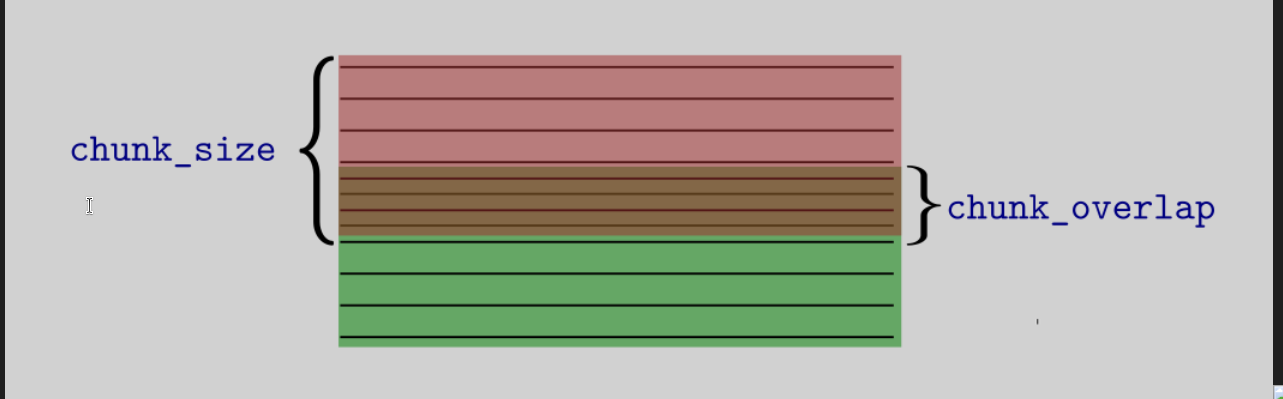




##  Text Splitters

**LangChain** ofrece varias implementaciones de **Text Splitters** para dividir texto basándose en:

- **Caracteres**  
- **Tokens**  
- **Líneas**  
- **Oraciones**  

### Algunos ejemplos comunes:

- **CharacterTextSplitter**: Divide el texto en función de caracteres.  
- **RecursiveCharacterTextSplitter**: Intenta dividir por varios delimitadores (como `\n` o espacios) hasta encontrar el tamaño adecuado.

# Tipos de Splitters

### `langchain.text_splitter`

- **CharacterTextSplitter()**: Implementación de división de texto basada en caracteres.  
- **MarkdownHeaderTextSplitter()**: Implementación de división de archivos markdown basada en encabezados especificados.  
- **TokenTextSplitter()**: Implementación de división de texto basada en tokens.  
- **SentenceTransformersTokenTextSplitter()**: Implementación de división de texto basada en tokens.  
- **RecursiveCharacterTextSplitter()**: Implementación de división de texto basada en caracteres. Intenta dividir recursivamente por diferentes caracteres para encontrar el que funcione.  
- **Language()**: Para CPP, Python, Ruby, Markdown, etc.  
- **NLTKTextSplitter()**: Implementación de división de texto basada en oraciones utilizando NLTK (Natural Language Tool Kit).  
- **SpacyTextSplitter()**: Implementación de división de texto basada en oraciones utilizando Spacy.  


In [25]:
from langchain.text_splitter import RecursiveCharacterTextSplitter, CharacterTextSplitter

## Configuración de un RecursiveCharacterTextSplitter

Dividimos un texto usando un tamaño de fragmento de 26 caracteres y un solapamiento de 4 caracteres.


In [27]:

chunk_size =26
chunk_overlap = 4


In [28]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size =  chunk_size,
    chunk_overlap = chunk_overlap

)

In [44]:

c_splitter = CharacterTextSplitter(
    chunk_size =  chunk_size,
    chunk_overlap = chunk_overlap

)

Probamos el divisor con una cadena de texto:

In [31]:
text1 = 'abcdefghijklmnopqrstuvwxyz'

In [32]:
r_splitter.split_text(text1)

['abcdefghijklmnopqrstuvwxyz']

El texto es demasiado corto y el splitter genera solo un chunk. Veamos un texto un poco mayor:


In [34]:
text2 = 'abcdefghijklmnopqrstuvwxyznopqrstuvwxyz'

In [35]:
r_splitter.split_text(text2)

['abcdefghijklmnopqrstuvwxyz', 'wxyznopqrstuvwxyz']

Aquí se ve el overlap


Los espacios también cuentan como caracteres. Veamos el resultado de dividir un texto que incluye espacios:

In [37]:
# Los esacios también son caracteres:
text3 = "a b c d e f g h i j k l m n o p q r s t u v w x y z"

Ahora hagámoslo con el spliter de caracteres:

In [45]:
c_splitter.split_text(text3)

['a b c d e f g h i j k l m n o p q r s t u v w x y z']

Lo que vemos es que no trata de dividirlo. Qué está pasando? debemos escoger el caracter separador. Po ejemplo `separator = ' '`

In [46]:
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap,
    separator = ' '
)
c_splitter.split_text(text3)

['a b c d e f g h i j k l m', 'l m n o p q r s t u v w x', 'w x y z']

## Recursive splitting details

`RecursiveCharacterTextSplitter` is recommended for generic text. 

In [47]:
some_text = """When writing documents, writers will use document structure to group content. \
This can convey to the reader, which idea's are related. For example, closely related ideas \
are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n  \
Paragraphs are often delimited with a carriage return or two carriage returns. \
Carriage returns are the "backslash n" you see embedded in this string. \
Sentences have a period at the end, but also, have a space.\
and words are separated by space."""

In [48]:
len(some_text)

496

In [49]:
c_splitter = CharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0,
    separator = ' '
)
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0, 
    separators=["\n\n", "\n", " ", ""] 
)

`separators=["\n\n", "\n", " ", ""] ` significa que hace el splir usando estos separadores en ese orden hasta que encuentre un tipo de separador que le sirva

In [55]:
c_splitter.split_text(some_text)
from IPython.display import Markdown, display
print(c_splitter.split_text(some_text))
display(Markdown(c_splitter.split_text(some_text)[0]))
display(Markdown(c_splitter.split_text(some_text)[1]))



['When writing documents, writers will use document structure to group content. This can convey to the reader, which idea\'s are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also,', 'have a space.and words are separated by space.']


When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. 

 Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also,

have a space.and words are separated by space.

In [60]:
display(Markdown(r_splitter.split_text(some_text)[0]))
display(Markdown(r_splitter.split_text(some_text)[1]))


When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.

Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also, have a space.and words are separated by space.

# Ejemplo: aplicado al pdf que cargamos anteriormente

In [61]:

from langchain.document_loaders import PyPDFLoader

output_path = ".content/"
file_path = output_path + 'attention.pdf'
loader = PyPDFLoader(file_path)
pages = loader.load()

In [62]:
from langchain.text_splitter import CharacterTextSplitter


In [64]:

text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=150,
    length_function=len
)

`   length_function=len` aquí len es una función de pyhton que mira el tamño de los carcteres

In [65]:
docs = text_splitter.split_documents(pages)

In [66]:
len(docs)

49

In [67]:
len(pages)

15

In [68]:
docs

[Document(metadata={'source': '.content/attention.pdf', 'page': 0, 'page_label': '1'}, page_content='Provided proper attribution is provided, Google hereby grants permission to\nreproduce the tables and figures in this paper solely for use in journalistic or\nscholarly works.\nAttention Is All You Need\nAshish Vaswani∗\nGoogle Brain\navaswani@google.com\nNoam Shazeer∗\nGoogle Brain\nnoam@google.com\nNiki Parmar∗\nGoogle Research\nnikip@google.com\nJakob Uszkoreit∗\nGoogle Research\nusz@google.com\nLlion Jones∗\nGoogle Research\nllion@google.com\nAidan N. Gomez∗ †\nUniversity of Toronto\naidan@cs.toronto.edu\nŁukasz Kaiser∗\nGoogle Brain\nlukaszkaiser@google.com\nIllia Polosukhin∗ ‡\nillia.polosukhin@gmail.com\nAbstract\nThe dominant sequence transduction models are based on complex recurrent or\nconvolutional neural networks that include an encoder and a decoder. The best\nperforming models also connect the encoder and decoder through an attention\nmechanism. We propose a new simple ne

## Almacenamiento en una base de datos vectorial

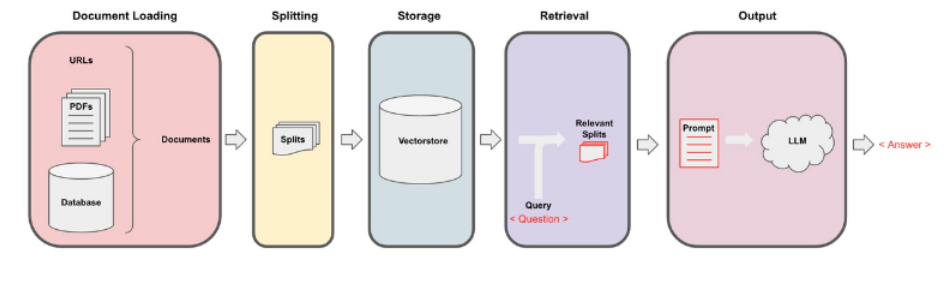
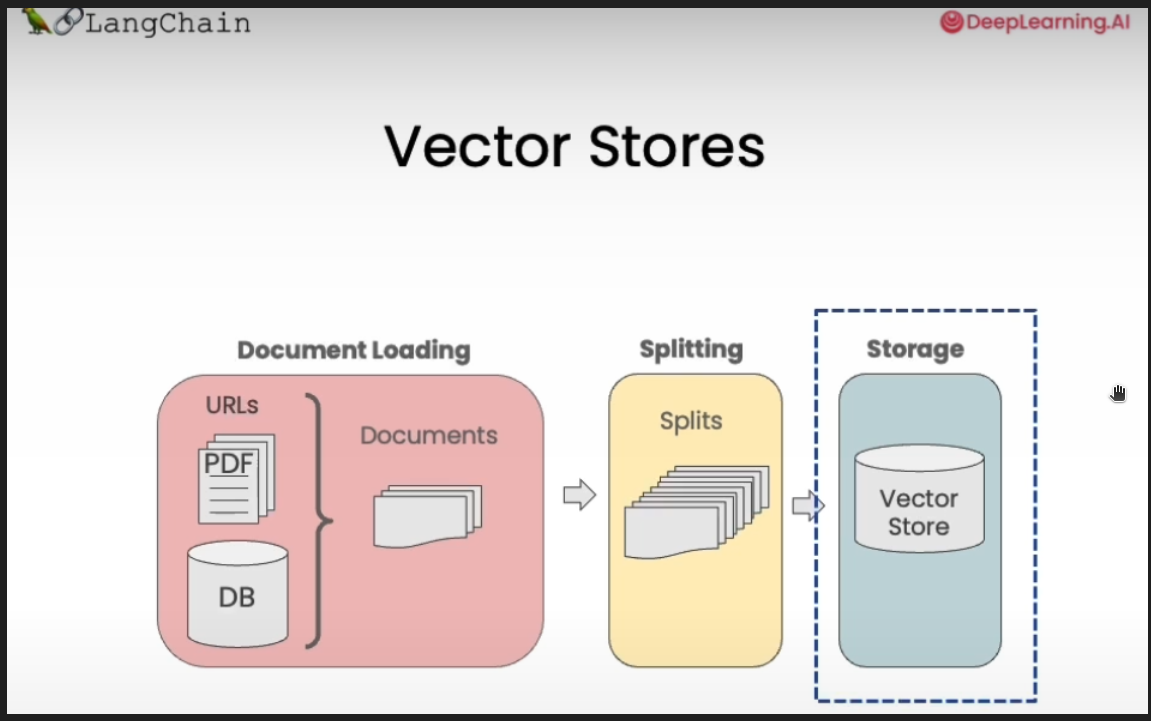

Recordemos el flujo:

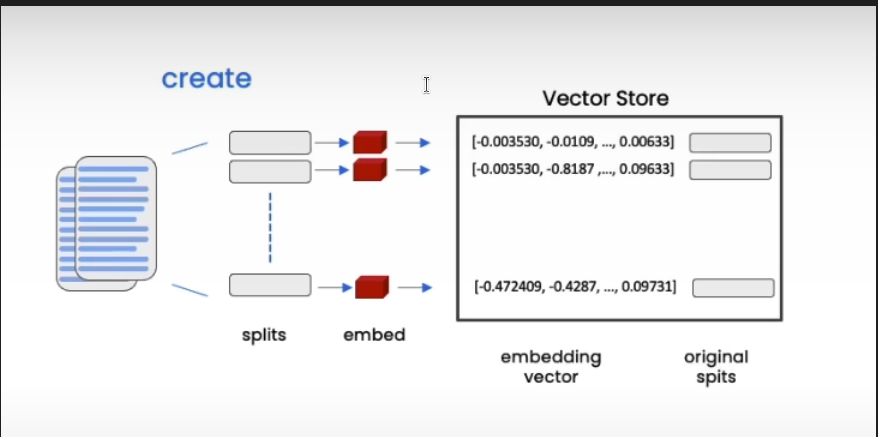

Acabamos de discutir la `Carga de Documentos` y la `División`. Los embeddings son el siguiente paso después de que hemos dividido nuestro documento y estamos listos para almacenarlos. Un embedding es una representación numérica de un fragmento de documento. Textos similares tienen representaciones similares en el espacio de embeddings, lo que significa que podemos comparar estos vectores y encontrar fragmentos de texto que son similares.

## Embedings

In [69]:
from langchain.embeddings import OpenAIEmbeddings 

In [70]:
embeding = OpenAIEmbeddings()

/tmp/ipykernel_15506/3533321096.py:1: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embeding = OpenAIEmbeddings()


In [71]:
sentence1 = "i like dogs"
sentence2 = "i like canines"
sentence3 = "the weather is ugly outside"

Las `sentence1` y `sentence2` son muy similares, pero la `sentence3` no.

In [72]:
embedings1 = embeding.embed_query(sentence1)
embedings2 = embeding.embed_query(sentence2)
embedings3 = embeding.embed_query(sentence3)

Podemos usar `numpy` para compararlas.

In [73]:
import numpy  as np

In [74]:
np.dot(embedings1, embedings2)

np.float64(0.9631510802407719)

In [75]:
np.dot(embedings1, embedings3)

np.float64(0.7702031204123156)

Usamos el producto escalar para compararlos. Ya que este es proporcional la distancia en entre los vectores. Recordemos que dados dos vectores $\bold{A}$  y $\bold{B}$ el producto escalar está deficido como    $\bold{A}   \cdot \bold{B}   = AB cos(\theta)$, como $cos(0) = 1$ entonces los vectores son mas cercanos entre más proximo este número esté de 1.

## Vectorstores




Las **vectorstores** son bases de datos que almacenan representaciones vectoriales (embeddings) de fragmentos de texto. Esto permite realizar búsquedas semánticas rápidas y eficientes. En este ejemplo, usaremos el PDF cargado previamente, lo dividiremos en fragmentos, generaremos embeddings y los guardaremos en `Chroma`, una vectorstore ligera y fácil de usar.



## Instalación de Dependencias

Para trabajar con `Chroma` y generar embeddings, necesitamos instalar algunas bibliotecas adicionales:

```bash
pip install chromadb sentence-transformers

`sentence-transformers:` Para generar embeddings (puedes usar otros como OpenAI, pero este es gratuito y local).




---

### Markdown (Carga y División del PDF)

```markdown
## Paso 1: Carga y División del PDF

Volvemos al ejemplo del PDF (`attention.pdf`). Lo cargaremos con `PyPDFLoader` y lo dividiremos en fragmentos usando `RecursiveCharacterTextSplitter`.

In [2]:
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Cargamos el PDF
output_path = ".content/"
file_path = output_path + "attention.pdf"
loader = PyPDFLoader(file_path)
documents = loader.load()

# Dividimos en fragmentos
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,  # Tamaño de cada fragmento
    chunk_overlap=50  # Solapamiento entre fragmentos
)
split_docs = text_splitter.split_documents(documents)

# Verificamos cuántos fragmentos tenemos
print(f"Se generaron {len(split_docs)} fragmentos del PDF.")

Se generaron 93 fragmentos del PDF.


# Vectorstores con OpenAIEmbeddings

En este ejemplo, usaremos `OpenAIEmbeddings` para generar representaciones vectoriales de los fragmentos del PDF `attention.pdf`. Estos embeddings se almacenarán en una vectorstore con `Chroma` para habilitar búsquedas semánticas avanzadas.

In [3]:
from langchain.embeddings import OpenAIEmbeddings

# Configuramos el modelo de embeddings de OpenAI
# Si no configuraste la variable de entorno, descomenta y añade tu clave:
# embedding_model = OpenAIEmbeddings(openai_api_key="tu-clave-aqui")
embedding_model = OpenAIEmbeddings()  # Usa la variable de entorno OPENAI_API_KEY

# Probamos con un fragmento para verificar
sample_chunk = split_docs[0].page_content
sample_embedding = embedding_model.embed_query(sample_chunk)
print(f"Dimensión del embedding: {len(sample_embedding)}")
print(f"Primeros 5 valores: {sample_embedding[:5]}")

/tmp/ipykernel_22089/3093679624.py:6: LangChainDeprecationWarning: The class `OpenAIEmbeddings` was deprecated in LangChain 0.0.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import OpenAIEmbeddings``.
  embedding_model = OpenAIEmbeddings()  # Usa la variable de entorno OPENAI_API_KEY


Dimensión del embedding: 1536
Primeros 5 valores: [-0.012028052625438306, 0.011993249100379726, 0.017206797596380607, -0.02774526400592465, -0.0014739236982953192]


## Paso 3: Almacenamiento en Chroma

Guardaremos los fragmentos y sus embeddings generados por OpenAI en una vectorstore de `Chroma`.

In [4]:
from langchain.vectorstores import Chroma

# Creamos la vectorstore con Chroma
vectorstore = Chroma.from_documents(
    documents=split_docs,  # Los fragmentos del PDF
    embedding=embedding_model,  # Embeddings de OpenAI
    persist_directory="./chroma_db_openai"  # Directorio para esta versión
)

# Verificamos cuántos documentos se almacenaron
print(f"Se almacenaron {vectorstore._collection.count()} fragmentos en la vectorstore.")

Se almacenaron 93 fragmentos en la vectorstore.


## Paso 4: Búsqueda Semántica

Con la vectorstore lista, podemos buscar fragmentos relevantes para una consulta como "attention mechanism".


In [6]:
# Realizamos una búsqueda semántica
query = "attention mechanism"
results = vectorstore.similarity_search(query, k=3)  # Top 3 fragmentos más similares

# Mostramos los resultados
for i, result in enumerate(results):
    print(f"Resultado {i + 1}:")
    print(result.page_content)
    print(f"Metadatos: {result.metadata}")
    print("-" * 50)

Resultado 1:
tion models in various tasks, allowing modeling of dependencies without regard to their distance in
the input or output sequences [2, 19]. In all but a few cases [27], however, such attention mechanisms
are used in conjunction with a recurrent network.
In this work we propose the Transformer, a model architecture eschewing recurrence and instead
relying entirely on an attention mechanism to draw global dependencies between input and output.
Metadatos: {'page': 1, 'page_label': '2', 'source': '.content/attention.pdf'}
--------------------------------------------------
Resultado 2:
but
its
application
should
be
just
-
this
is
what
we
are
missing
,
in
my
opinion
.
<EOS>
<pad>
Figure 5: Many of the attention heads exhibit behaviour that seems related to the structure of the
sentence. We give two such examples above, from two different heads from the encoder self-attention
at layer 5 of 6. The heads clearly learned to perform different tasks.
15
Metadatos: {'page': 14, 'page_la

## Persistencia de la Vectorstore

La base de datos se guarda en `./chroma_db_openai`. Para cargarla más tarde:

In [7]:
# Cargar la vectorstore existente
loaded_vectorstore = Chroma(
    persist_directory="./chroma_db_openai",
    embedding_function=embedding_model
)

# Verificamos que se cargó
print(f"Fragmentos cargados desde disco: {loaded_vectorstore._collection.count()}")

Fragmentos cargados desde disco: 93


/tmp/ipykernel_22089/642427867.py:2: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  loaded_vectorstore = Chroma(


In [10]:
query = "embeddings"
results = loaded_vectorstore.similarity_search(query, k=3)  # Top 3 fragmentos más similares

# Mostramos los resultados
for i, result in enumerate(results):
    print(f"Resultado {i + 1}:")
    print(result.page_content)
    print(f"Metadatos: {result.metadata}")
    print("-" * 50)

Resultado 1:
Zhou, and Yoshua Bengio. A structured self-attentive sentence embedding. arXiv preprint
arXiv:1703.03130, 2017.
[23] Minh-Thang Luong, Quoc V . Le, Ilya Sutskever, Oriol Vinyals, and Lukasz Kaiser. Multi-task
sequence to sequence learning. arXiv preprint arXiv:1511.06114, 2015.
[24] Minh-Thang Luong, Hieu Pham, and Christopher D Manning. Effective approaches to attention-
based neural machine translation. arXiv preprint arXiv:1508.04025, 2015.
11
Metadatos: {'page': 10, 'page_label': '11', 'source': '.content/attention.pdf'}
--------------------------------------------------
Resultado 2:
2006.
[30] Ofir Press and Lior Wolf. Using the output embedding to improve language models. arXiv
preprint arXiv:1608.05859, 2016.
[31] Rico Sennrich, Barry Haddow, and Alexandra Birch. Neural machine translation of rare words
with subword units. arXiv preprint arXiv:1508.07909, 2015.
[32] Noam Shazeer, Azalia Mirhoseini, Krzysztof Maziarz, Andy Davis, Quoc Le, Geoffrey Hinton,
and Jeff De

## RetrievalQA

Combinaremos la vectorstore con un modelo de lenguaje de OpenAI (`gpt-3.5-turbo` por defecto) para responder preguntas. `RetrievalQA` buscará fragmentos relevantes en la vectorstore y los usará como contexto para generar respuestas.

In [11]:
from langchain.chains import RetrievalQA
from langchain.chat_models import ChatOpenAI

# Configuramos el modelo de lenguaje
llm = ChatOpenAI(
    model_name="gpt-3.5-turbo",
    temperature=0  # Respuestas más precisas y menos creativas
)

# Creamos la cadena RetrievalQA
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",  # Usa todos los fragmentos relevantes directamente
    retriever=vectorstore.as_retriever(search_kwargs={"k": 3}),  # Top 3 fragmentos más similares
    return_source_documents=True  # Devuelve los fragmentos usados como fuente
)

/tmp/ipykernel_22089/2594432852.py:5: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(


## Preguntas al PDF

Ahora podemos preguntar algo sobre el contenido del PDF, como el mecanismo de atención descrito en `attention.pdf`. Mostraremos la respuesta y las fuentes utilizadas.

In [12]:
# Hacemos una pregunta
query = "¿Qué es el mecanismo de atención en redes neuronales?"
result = qa_chain({"query": query})

# Mostramos la respuesta
print("Respuesta:")
print(result["result"])
print("\nFragmentos utilizados como fuente:")
for i, doc in enumerate(result["source_documents"]):
    print(f"Fuente {i + 1}:")
    print(doc.page_content)
    print(f"Metadatos: {doc.metadata}")
    print("-" * 50)

/tmp/ipykernel_22089/764083759.py:3: LangChainDeprecationWarning: The method `Chain.__call__` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.
  result = qa_chain({"query": query})


Respuesta:
El mecanismo de atención en redes neuronales es una técnica que permite a la red enfocarse en partes específicas de la entrada durante el proceso de aprendizaje. Esto es útil para tareas como traducción automática, donde la red puede aprender a dar más importancia a ciertas palabras o partes de la oración en función del contexto.

Fragmentos utilizados como fuente:
Fuente 1:
2017.
[19] Yoon Kim, Carl Denton, Luong Hoang, and Alexander M. Rush. Structured attention networks.
In International Conference on Learning Representations, 2017.
[20] Diederik Kingma and Jimmy Ba. Adam: A method for stochastic optimization. In ICLR, 2015.
[21] Oleksii Kuchaiev and Boris Ginsburg. Factorization tricks for LSTM networks. arXiv preprint
arXiv:1703.10722, 2017.
[22] Zhouhan Lin, Minwei Feng, Cicero Nogueira dos Santos, Mo Yu, Bing Xiang, Bowen
Metadatos: {'page': 10, 'page_label': '11', 'source': '.content/attention.pdf'}
--------------------------------------------------
Fuente 2:
used su



Probemos otra pregunta para demostrar la flexibilidad de `RetrievalQA`.


In [14]:
# Otra pregunta
query2 = "¿Cómo se usa la atención ?"
result2 = qa_chain({"query": query2})

# Mostramos la respuesta
print("Respuesta:")
print(result2["result"])
print("\nFragmentos utilizados como fuente:")
for i, doc in enumerate(result2["source_documents"]):
    print(f"Fuente {i + 1}:")
    print(doc.page_content)
    print(f"Metadatos: {doc.metadata}")
    print("-" * 50)

Respuesta:
La atención se utiliza en el contexto de modelos de aprendizaje automático, como en el caso de la atención en el mecanismo de atención de un modelo de Transformer. La atención se aplica para permitir que el modelo se enfoque en partes específicas de la entrada durante el proceso de aprendizaje y predicción.

Fragmentos utilizados como fuente:
Fuente 1:
but
its
application
should
be
just
-
this
is
what
we
are
missing
,
in
my
opinion
.
<EOS>
<pad>
Figure 5: Many of the attention heads exhibit behaviour that seems related to the structure of the
sentence. We give two such examples above, from two different heads from the encoder self-attention
at layer 5 of 6. The heads clearly learned to perform different tasks.
15
Metadatos: {'page': 14, 'page_label': '15', 'source': '.content/attention.pdf'}
--------------------------------------------------
Fuente 2:
.
<EOS>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
Figure 3: An example of the attention mechanism following long-distance dependenc

In [2]:
from unstructured.partition.pdf import partition_pdf

/home/jcamilomacias/anaconda3/envs/DiplomadoIA_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

output_path = ".content/"
file_path = output_path + 'attention.pdf'

In [4]:
chunks = partition_pdf(filename=file_path)

In [5]:
chunks

In [6]:
# Muestra los elementos extraídos
for chunk in chunks:
    print(chunk)

3 2 0 2
g u A 2
] L C . s c [
7 v 2 6 7 3 0 . 6 0 7 1 : v i X r a
Provided proper attribution is provided, Google hereby grants permission to reproduce the tables and figures in this paper solely for use in journalistic or scholarly works.
Attention Is All You Need
Ashish Vaswani∗ Google Brain avaswani@google.com
Noam Shazeer∗ Google Brain noam@google.com
Niki Parmar∗ Google Research nikip@google.com
Jakob Uszkoreit∗ Google Research usz@google.com
Llion Jones∗ Google Research llion@google.com
Aidan N. Gomez∗ † University of Toronto aidan@cs.toronto.edu
Łukasz Kaiser∗ Google Brain lukaszkaiser@google.com
Illia Polosukhin∗ ‡ illia.polosukhin@gmail.com
Abstract
The dominant sequence transduction models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, based solely on attention mec

In [7]:
# Reference: https://docs.unstructured.io/open-source/core-functionality/chunking
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # extract tables
    strategy="hi_res",                     # mandatory to infer tables

    extract_image_block_types=["Image"],   # Add 'Table' to list to extract image of tables
    # image_output_dir_path=output_path,   # if None, images and tables will saved in base64

    extract_image_block_to_payload=True,   # if true, will extract base64 for API usage

    chunking_strategy="by_title",          # or 'basic'
    max_characters=10000,                  # defaults to 500
    combine_text_under_n_chars=2000,       # defaults to 0
    new_after_n_chars=6000,

    # extract_images_in_pdf=True,          # deprecated
)

The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.


In [8]:
from unstructured.partition.pdf import partition_pdf

# Define paths
output_path = ".content/"
file_path = output_path + 'attention.pdf'

# Partition the PDF
chunks = partition_pdf(
    filename=file_path,
    infer_table_structure=True,            # Extract tables as structured data
    strategy="hi_res",                     # Required for table and image extraction
    extract_image_block_types=["Image"],   # Extract images (add "Table" for table images)
    extract_image_block_to_payload=True,   # Store images as base64 in the output
    chunking_strategy="by_title",          # Chunk by document sections/titles
    max_characters=10000,                  # Max characters per chunk
    combine_text_under_n_chars=2000,       # Combine small text blocks
    new_after_n_chars=6000,               # Start new chunk after 6000 characters
)

# Inspect the output
for i, chunk in enumerate(chunks):
    print(f"Chunk {i+1}:")
    print(f"Type: {chunk.type}")
    print(f"Text: {chunk.text[:200]}...")  # Show first 200 characters
    if chunk.metadata.get("image_base64"):
        print("Contains base64-encoded image")
    print("-" * 50)

Chunk 1:


AttributeError: 'CompositeElement' object has no attribute 'type'